<a href="https://colab.research.google.com/github/fralfaro/ICS40125/blob/main/docs/labs/lab_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# ICS40125 - Laboratorio N°10

**Objetivo**: Analizar y modelar series temporales de datos delictivos en Montreal, aplicando métodos estadísticos y de aprendizaje automático para la predicción.

> **Nota**: Puede ayudarse de algún asistente virtual como **ChatGPT, Gemini** u otros, así como del autocompletado de **Google Colab**, para avanzar en este laboratorio debido a su extensión.


### Conjunto de datos



<img src="https://svgsilh.com/svg/3350822.svg" width="350"  align="center"/>


El conjunto de datos **`interventionscitoyendo.csv`** proviene del *Service de police de la Ville de Montréal* (SPVM) y contiene el registro de todos los **actos delictivos ocurridos en Montreal entre 2015 y agosto de 2020**.

Cada incidente está clasificado en **categorías generales de delito** e incluye información contextual como la **ubicación geográfica**, la **fecha y hora** del suceso, así como otros atributos relevantes para el análisis.

Este dataset resulta especialmente útil para estudios de **series temporales**, ya que permite agrupar los delitos por intervalos de tiempo (días, semanas, meses) y analizar patrones de comportamiento delictual en la ciudad.

> **Nota**: Puede consultarse más información oficial en el [portal de datos abiertos de Montreal](https://donnees.montreal.ca/ville-de-montreal/actes-criminels).


In [41]:
# librerias

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX


# graficos incrustados
plt.style.use('fivethirtyeight')
%matplotlib inline

# parametros esteticos de seaborn
sns.set_palette("deep", desat=.6)
sns.set_context(rc={"figure.figsize": (12, 4)})

In [42]:
# metrics


def mae(targets, predictions) -> float:
    """
    Calculo de la metrica: mean absolute error (MAE)
    :param targets: valor real
    :param predictions: valor estimado
    :return: valor de la metrica
    """
    error = predictions - targets
    return round(np.abs(error).mean(), 4)


def mse(targets, predictions) -> float:
    """
    Calculo de la metrica: mean squared error (MSE)
    :param targets: valor real
    :param predictions: valor estimado
    :return: valor de la metrica
    """
    error = predictions - targets
    return round((error ** 2).mean(), 4)


def rmse(targets, predictions) -> float:
    """
    Calculo de la metrica: root mean squared error (RMSE)
    :param targets: valor real
    :param predictions: valor estimado
    :return: valor de la metrica
    """
    error = predictions - targets
    return round(np.sqrt((error ** 2).mean()), 4)


# b) Percentage errors

def mape(targets, predictions) -> float:
    """
    Calculo de la metrica: mean absolute percentage error (MAPE)
    :param targets: valor real
    :param predictions: valor estimado
    :return: valor de la metrica
    """
    error = predictions - targets

    if any(x == 0 for x in targets):
        return np.inf
    else:
        return round(np.abs(error / targets).mean(),4)


def maape(targets, predictions) -> float:
    """
    Calculo de la metrica:  mean arctangent percentage error  (MAAPE)
    :param targets: valor real
    :param predictions: valor estimado
    :return: valor de la metrica
    """

    error = predictions - targets

    if any((x, y) == (0, 0) for x, y in zip(predictions, targets)):
        return np.inf

    else:
        return round(np.arctan(np.abs(error / targets)).mean(),4)


def wmape(targets, predictions) -> float:
    """
    Calculo de la metrica:  weighted mean absolute percentage error (WMAPE)
    :param targets: valor real
    :param predictions: valor estimado
    :return: valor de la metrica
    """
    error = predictions - targets
    sum_values = np.sum(targets)

    if sum_values == 0:
        return np.inf
    else:
        return round(np.abs(error).sum() / sum_values,4)


def mmape(targets, predictions) -> float:
    """
    Calculo de la metrica: modified mean absolute percentage error (MMAPE)
    :param targets: valor real
    :param predictions: valor estimado
    :return: valor de la metrica
    """
    error = np.abs(predictions - targets)
    denom = 1 + np.abs(targets)

    return round(np.mean(error / denom),4)


def smape(targets, predictions) -> float:
    """
    Calculo de la metrica: symmetric mean absolute percentage error (SMAPE)
    :param targets: valor real
    :param predictions: valor estimado
    :return: valor de la metrica
    """
    error = predictions - targets
    sum_values = np.abs(predictions) + np.abs(targets)

    if any(x == 0 for x in sum_values):
        return np.inf

    else:
        return round(2 * np.mean(np.abs(error) / sum_values),4)

def summary_metrics(df) -> pd.DataFrame:
    """
    Aplicar las distintas metricas definidas
    :param df:  dataframe con las columnas: ['y','yhat']
    :return: dataframe con las metricas especificadas
    """
    df_result = pd.DataFrame()

    y_true = df['y']
    y_pred = df['yhat']

    df_result['mae'] = [round(mae(y_true, y_pred), 4)]
    df_result['mse'] = [round(mse(y_true, y_pred), 4)]
    df_result['rmse'] = [round(rmse(y_true, y_pred), 4)]

    df_result['mape'] = [round(mape(y_true, y_pred), 4)]
    df_result['maape'] = [round(maape(y_true, y_pred), 4)]
    df_result['wmape'] = [round(wmape(y_true, y_pred), 4)]
    df_result['mmape'] = [round(mmape(y_true, y_pred), 4)]
    df_result['smape'] = [round(smape(y_true, y_pred), 4)]

    # nombre del modelo por defecto
    #try:
    #    model = df['model'][0]
    #    df_result['model'] = [model]
    #except:
    #    df_result['model'] = ['---']

    return df_result

In [43]:
# read data

validate_categorie = [
  'Introduction', 'Méfait','Vol dans / sur véhicule à moteur', 'Vol de véhicule à moteur',
]

df = pd.read_csv("https://raw.githubusercontent.com/fralfaro/ICS40125/main/docs/labs/data/interventionscitoyendo.csv", sep=",", encoding='latin-1')
df.columns = df.columns.str.lower()
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')

df = df.loc[lambda x: x['categorie'].isin(validate_categorie)]
df = df.sort_values(['categorie','date'])
df.head()

,categorie,date,quart,pdq,x,y,longitude,latitude
3462,Introduction,2015-01-01,jour,42.0,297210.375006,5.050179e+06,-73.597273,45.591480
8370,Introduction,2015-01-01,soir,13.0,297145.531007,5.032845e+06,-73.597834,45.435501
11968,Introduction,2015-01-01,nuit,8.0,289215.072000,5.036423e+06,-73.699308,45.467564
12763,Introduction,2015-01-01,soir,27.0,293203.472992,5.045436e+06,-73.648516,45.548740
13686,Introduction,2015-01-01,soir,44.0,298915.433995,5.046912e+06,-73.575381,45.562090


Como tenemos muchos datos por categoría a nivel de día, agruparemos a nivel de **semanas** y separaremos cada serie temporal.

In [44]:
cols = ['date','pdq']
y_s1 = df.loc[lambda x: x.categorie == validate_categorie[0] ][cols].set_index('date').resample('W').mean()
y_s2 = df.loc[lambda x: x.categorie == validate_categorie[1] ][cols].set_index('date').resample('W').mean()
y_s3 = df.loc[lambda x: x.categorie == validate_categorie[2] ][cols].set_index('date').resample('W').mean()
y_s4 = df.loc[lambda x: x.categorie == validate_categorie[3] ][cols].set_index('date').resample('W').mean()



El objetivo de este laboratorio es realizar un **análisis integral** del conjunto de datos, aplicando técnicas de visualización y modelado de series temporales. Para ello, se deben abordar las siguientes tareas:

1. **Visualizar las series temporales** \$y\_{si}, ; i=1,2,3,4\$, generando gráficos que permitan identificar patrones, tendencias y estacionalidades.



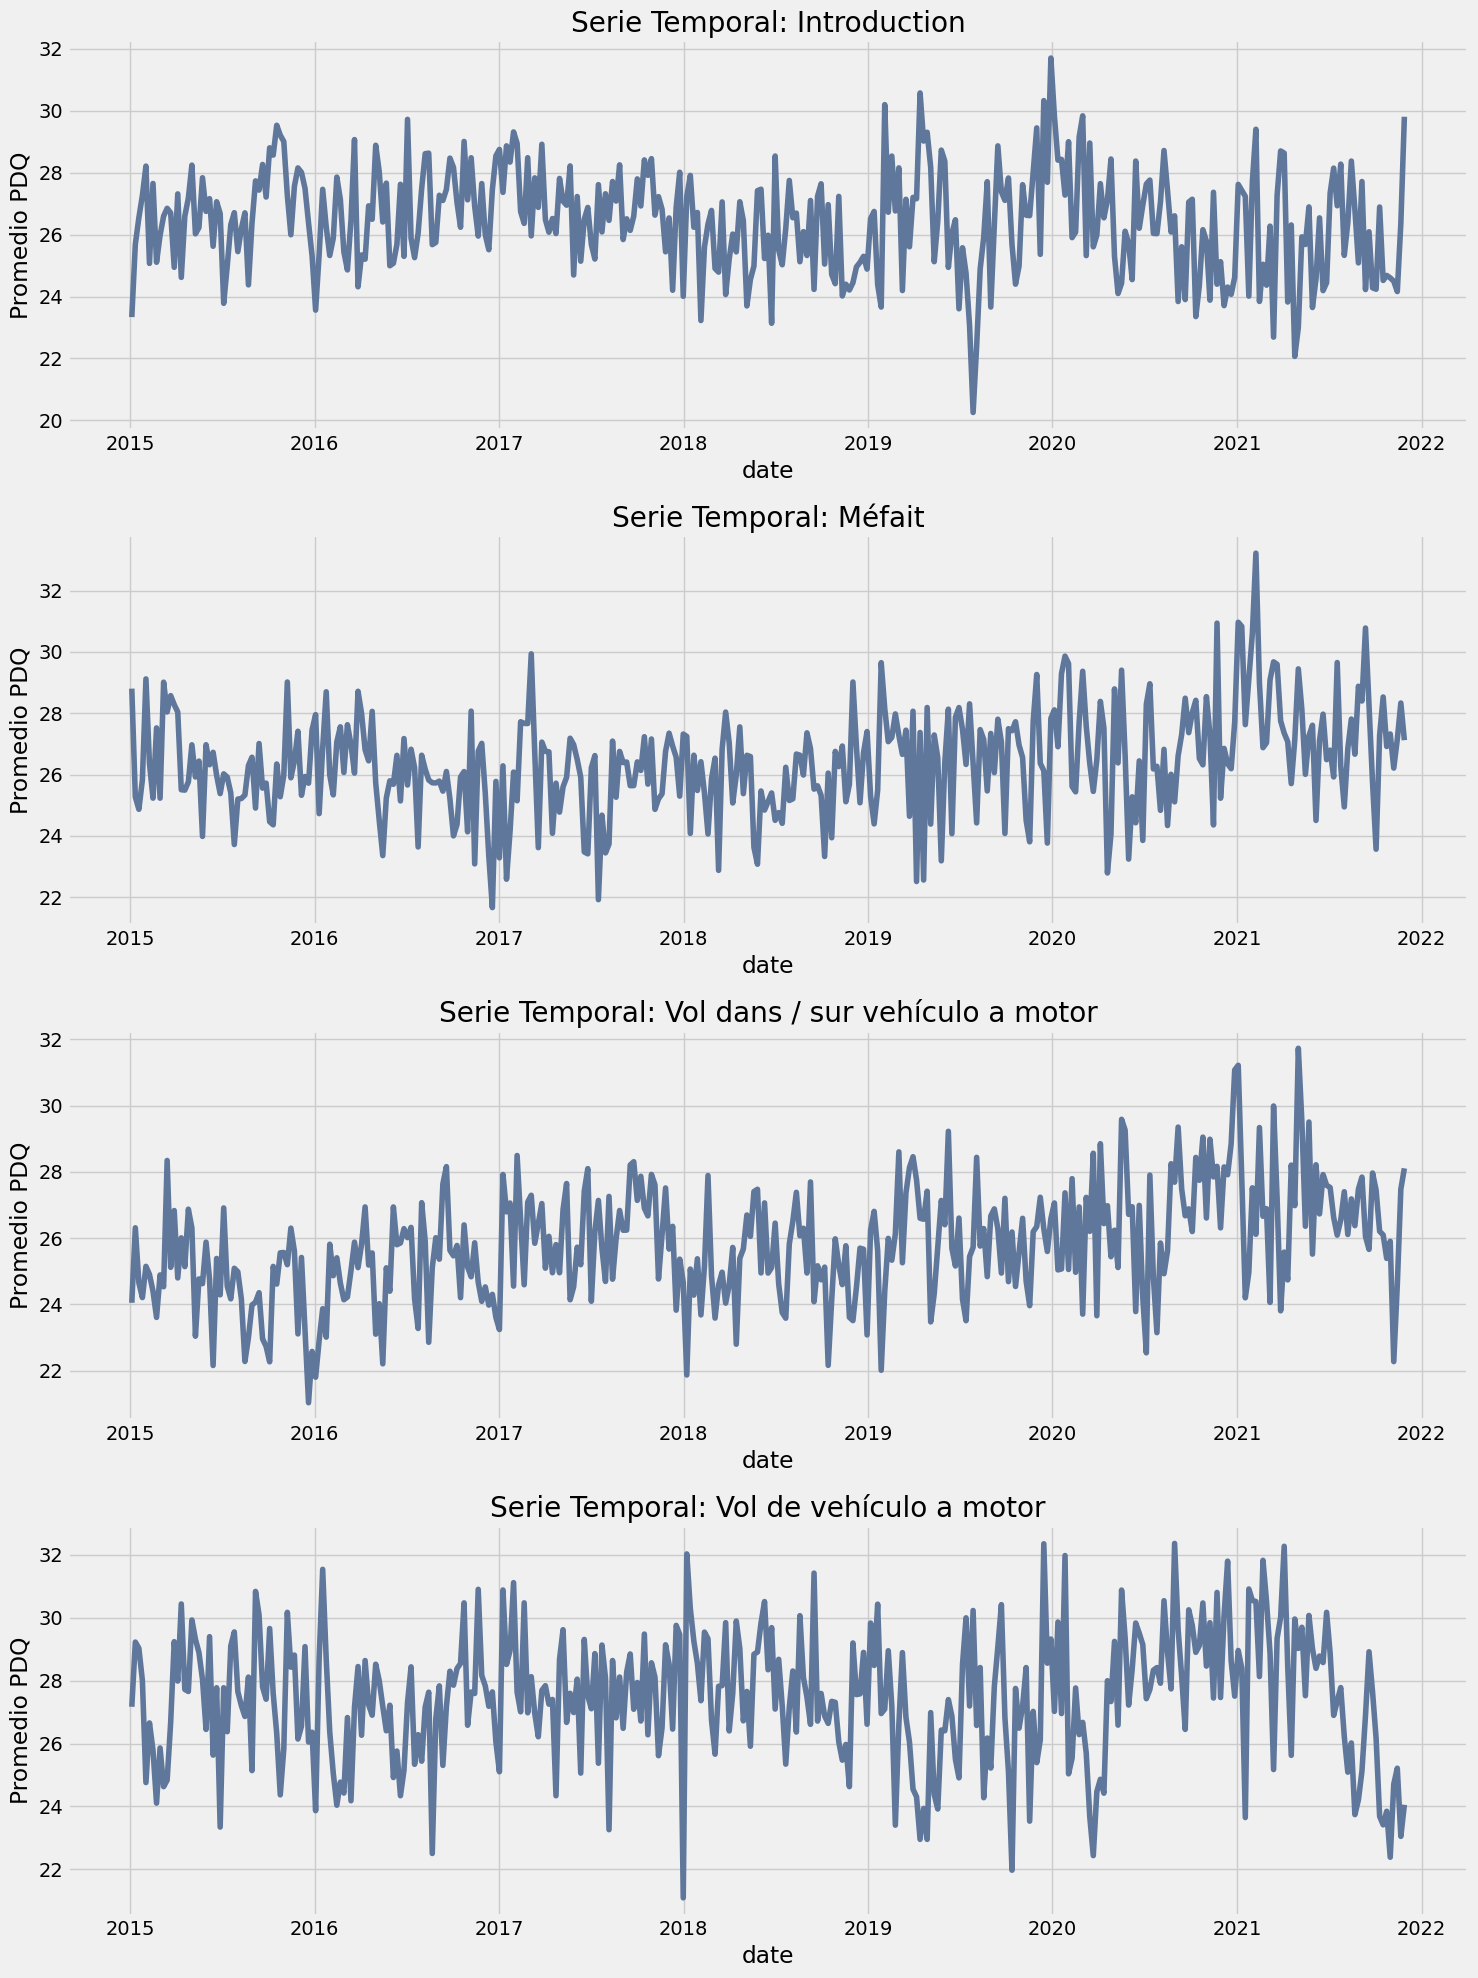

In [49]:
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(15, 20))

series_names = ['Introduction', 'Méfait', 'Vol dans / sur vehículo a motor', 'Vol de vehículo a motor']
series_data = [y_s1, y_s2, y_s3, y_s4]

for i, (data, name) in enumerate(zip(series_data, series_names)):
    if not data.empty:
        sns.lineplot(ax=axes[i], x=data.index, y='pdq', data=data)
        axes[i].set_title(f'Serie Temporal: {name}')
        axes[i].set_xlabel('date')
        axes[i].set_ylabel('Promedio PDQ')
    else:
        axes[i].set_title(f'Serie Temporal: {name} (Vacía)')
        axes[i].set_xlabel('date')
        axes[i].set_ylabel('Promedio PDQ')
        axes[i].text(0.5, 0.5, 'No hay datos para mostrar', horizontalalignment='center', verticalalignment='center', transform=axes[i].transAxes, fontsize=12, color='gray')

plt.tight_layout()
plt.show()



1. Seleccione una de las series temporales \$y\_{si}, ; i=1,2,3,4\$ y desarrolle lo siguiente:

* **Análisis exploratorio**: examine la serie elegida identificando patrones, tendencias y posibles estacionalidades.
* **Modelado con SARIMA**: ajuste un modelo \$SARIMA(p,d,q) \times (P,D,Q,S)\$ probando distintas configuraciones de hiperparámetros. Compare resultados, seleccione la mejor configuración y justifique su elección.
* **Validación del modelo**: evalúe los residuos del modelo óptimo y determine si se comportan como **ruido blanco**.

> **Nota**: Utilice como `target_date` = `'2021-01-01'`. Recuerde que la columna de valores se llama `pdq`.



## 2. Análisis Exploratorio y Modelado SARIMA (Serie 'Introduction')

### 2.1 Análisis Exploratorio de la Serie 'Introduction' (y_s1)

Primero, visualizaremos la serie `y_s1` para observar sus características principales, como tendencia y estacionalidad. Luego, utilizaremos la descomposición estacional para separar la serie en sus componentes de tendencia, estacionalidad y residuo. Finalmente, analizaremos las funciones de autocorrelación (ACF) y autocorrelación parcial (PACF) para identificar posibles órdenes para el modelo SARIMA.

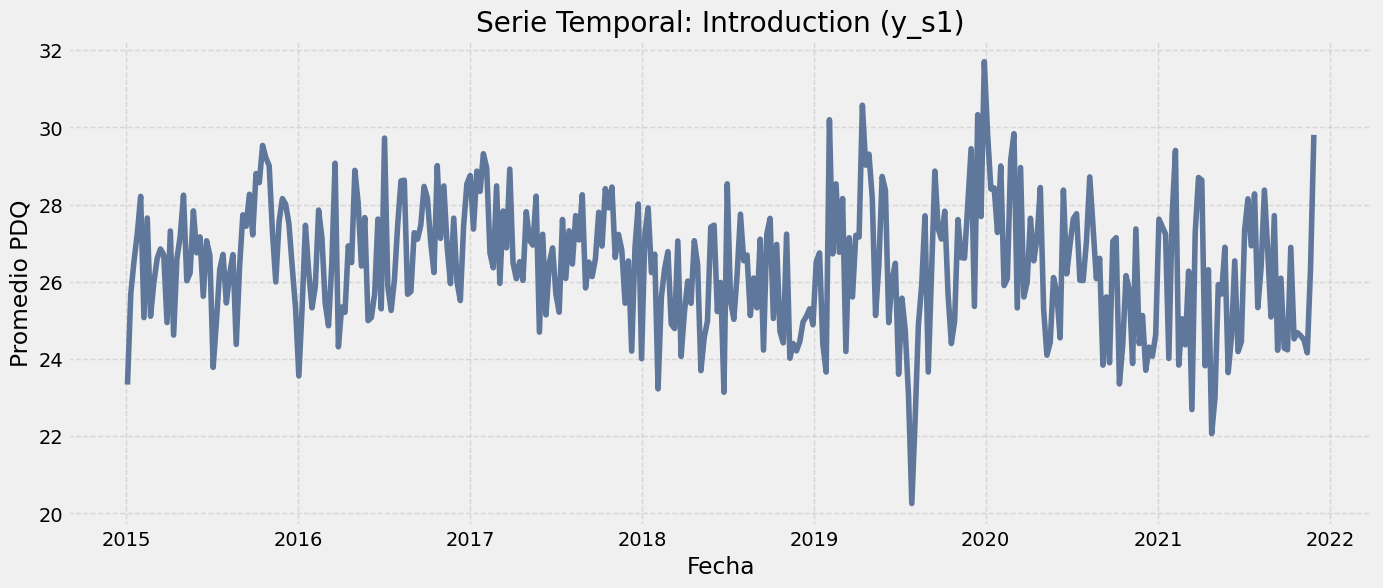

In [50]:
# Visualización de la serie temporal y_s1
plt.figure(figsize=(15, 6))
sns.lineplot(x=y_s1.index, y='pdq', data=y_s1)
plt.title('Serie Temporal: Introduction (y_s1)')
plt.xlabel('Fecha')
plt.ylabel('Promedio PDQ')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

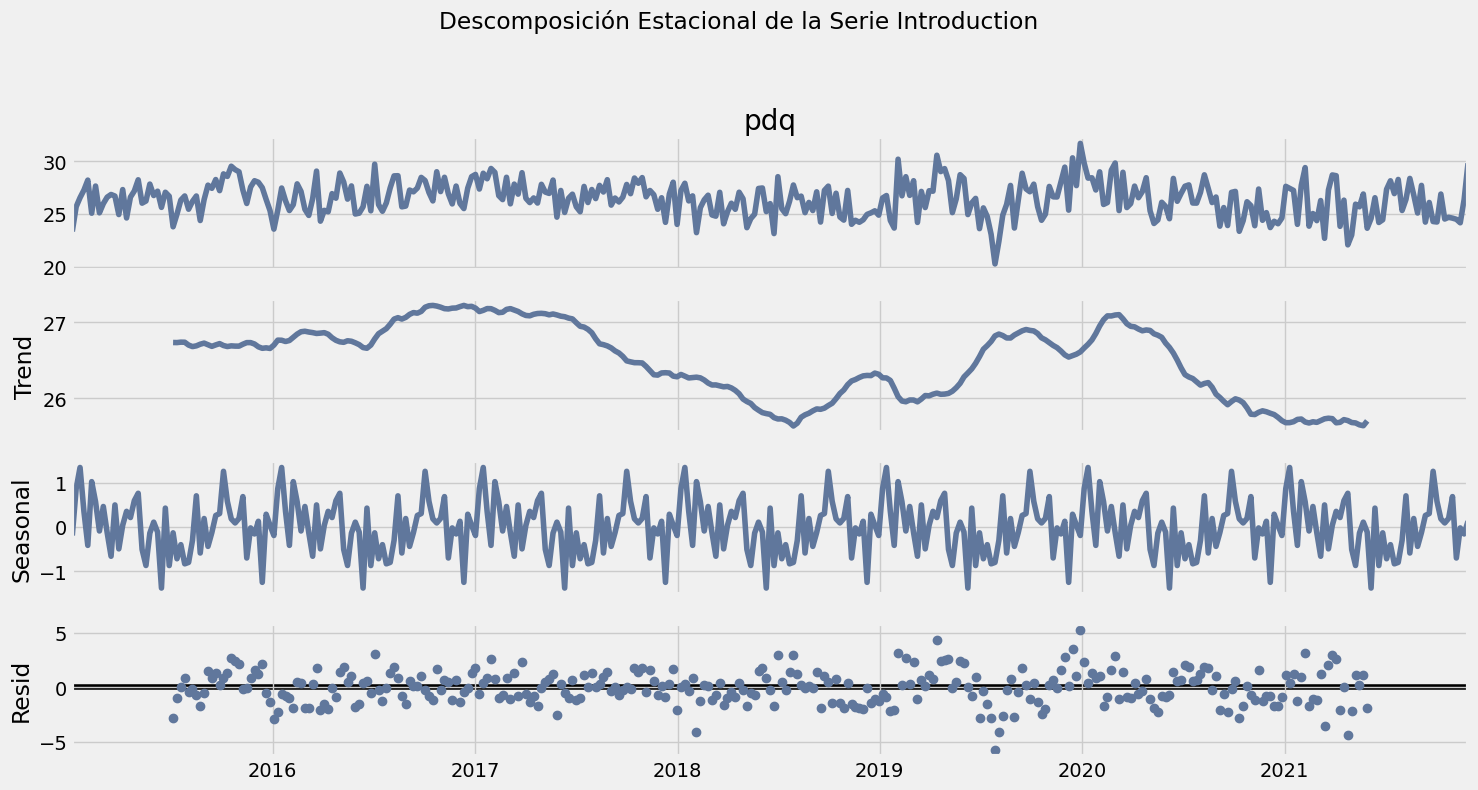

In [51]:
# Descomposición Estacional de y_s1
# Asumimos una estacionalidad semanal, por lo que S=52 semanas en un año.
# Para datos semanales, la frecuencia estacional suele ser 52 si hay un ciclo anual claro.
# Sin embargo, como el resample es 'W', el ciclo se observa cada 52 puntos, que corresponde a 1 año

decomposition = sm.tsa.seasonal_decompose(y_s1['pdq'], model='additive', period=52)
fig = decomposition.plot()
fig.set_size_inches(15, 8)
plt.suptitle('Descomposición Estacional de la Serie Introduction', y=1.02) # Ajustar el título general
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Ajustar diseño para evitar solapamiento de título
plt.show()

Observando la descomposición, podemos identificar la tendencia general, los patrones estacionales recurrentes y el componente residual. Ahora, generaremos los gráficos de ACF y PACF para ayudar a determinar los órdenes `p, d, q` y `P, D, Q` del modelo SARIMA.

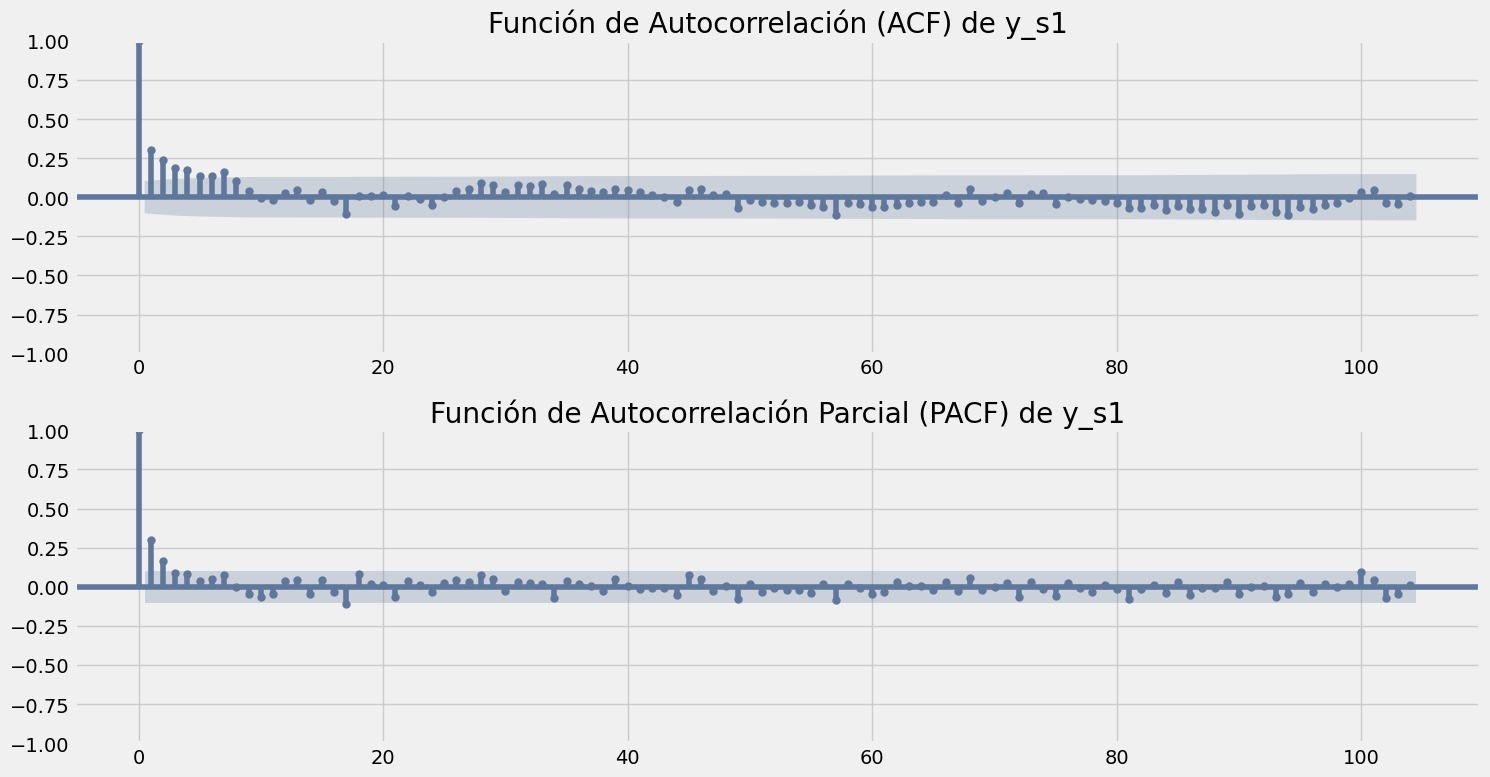

In [52]:
# Gráficos de ACF y PACF para y_s1

fig, axes = plt.subplots(2, 1, figsize=(15, 8))

sm.graphics.tsa.plot_acf(y_s1['pdq'], lags=104, ax=axes[0]) # 2 años de datos semanales (52*2)
axes[0].set_title('Función de Autocorrelación (ACF) de y_s1')

sm.graphics.tsa.plot_pacf(y_s1['pdq'], lags=104, ax=axes[1])
axes[1].set_title('Función de Autocorrelación Parcial (PACF) de y_s1')

plt.tight_layout()
plt.show()

### 2.2 Modelado con SARIMA

Para el modelado SARIMA, utilizaremos los conocimientos obtenidos del análisis exploratorio (ACF y PACF) para definir un rango de órdenes `(p, d, q)` y `(P, D, Q, S)` a probar. Luego, iteraremos a través de estas combinaciones, ajustaremos modelos SARIMA y evaluaremos su rendimiento utilizando métricas como el MAE, MSE, RMSE, etc.

In [53]:
import warnings

warnings.filterwarnings('ignore') # Ignorar advertencias, especialmente de optimización de SARIMA

sarima_results = []

for param in params:
    try:
        model = SarimaModels(param)
        metrics = model.metrics(y_s1, target_date)
        metrics['param_tuple'] = str(param) # Guardar el parámetro como string para mejor visualización
        sarima_results.append(metrics)
    except Exception as e:
        # print(f"Error al ajustar el modelo SARIMA con parámetros {param}: {e}")
        continue

df_sarima_results = pd.concat(sarima_results, ignore_index=True)

# Encontrar el mejor modelo basado en una métrica (ej. RMSE)
best_sarima_model_row = df_sarima_results.loc[df_sarima_results['rmse'].idxmin()]
best_param_str = best_sarima_model_row['param_tuple']

# Convertir el string de vuelta a tupla para usarlo en el modelo final
# Esto es un truco para manejar la conversión de string a tupla de tuplas
best_param_tuple = eval(best_param_str)

print("Mejor modelo SARIMA encontrado:")
print(best_sarima_model_row)

best_sarima_model = SarimaModels(best_param_tuple)


Mejor modelo SARIMA encontrado:
mae                                1.5876
mse                                3.4224
rmse                                 1.85
mape                               0.0622
maape                               0.062
wmape                              0.0614
mmape                              0.0599
smape                              0.0614
model           SARIMA_(0,0,0)X(1,0,1,12)
param_tuple    ((0, 0, 0), (1, 0, 1, 12))
Name: 5, dtype: object


In [46]:
# creando clase SarimaModels

class SarimaModels:
    def __init__(self,params):

        self.params = params


    @property
    def name_model(self):
        return f"SARIMA_{self.params[0]}X{self.params[1]}".replace(' ','')

    @staticmethod
    def test_train_model(y,date):
        mask_ds = y.index < date

        y_train = y[mask_ds]
        y_test = y[~mask_ds]

        return y_train, y_test

    def fit_model(self,y,date):
        y_train, y_test = self.test_train_model(y,date )
        model = SARIMAX(y_train,
                        order=self.params[0],
                        seasonal_order=self.params[1],
                        enforce_stationarity=False,
                        enforce_invertibility=False)

        model_fit = model.fit(disp=0)

        return model_fit

    def df_testig(self,y,date):
        y_train, y_test = self.test_train_model(y,date )
        model = SARIMAX(y_train,
                        order=self.params[0],
                        seasonal_order=self.params[1],
                        enforce_stationarity=False,
                        enforce_invertibility=False)

        model_fit = model.fit(disp=0)

        start_index = y_test.index.min()
        end_index = y_test.index.max()

        preds = model_fit.get_prediction(start=start_index,end=end_index, dynamic=False)
        df_temp = pd.DataFrame(
            {
                'y':y_test['pdq'],
                'yhat': preds.predicted_mean
            }
        )

        return df_temp

    def metrics(self,y,date):
        df_temp = self.df_testig(y,date)
        df_metrics = summary_metrics(df_temp)
        df_metrics['model'] = self.name_model

        return df_metrics

# definir parametros

import itertools

p = d = q = range(0, 2)
pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], 12) for x in list(itertools.product(p, d, q))]

params = list(itertools.product(pdq,seasonal_pdq))
target_date = '2021-01-01'

In [47]:
# fix me please

### 2.3 Validación del Modelo SARIMA

Una vez seleccionado el mejor modelo SARIMA, es fundamental validar sus residuos para asegurar que se comportan como ruido blanco. Esto significa que los residuos deben ser independientes, tener media cero y varianza constante. Evaluaremos esto mediante:

1.  **Gráfico de Residuos**: Visualización de los residuos a lo largo del tiempo.
2.  **Histograma y KDE de Residuos**: Para verificar la normalidad y la media cero.
3.  **Q-Q Plot**: Para comparar la distribución de los residuos con una distribución normal teórica.
4.  **Correlogramas (ACF de Residuos)**: Para verificar la ausencia de autocorrelación en los residuos.

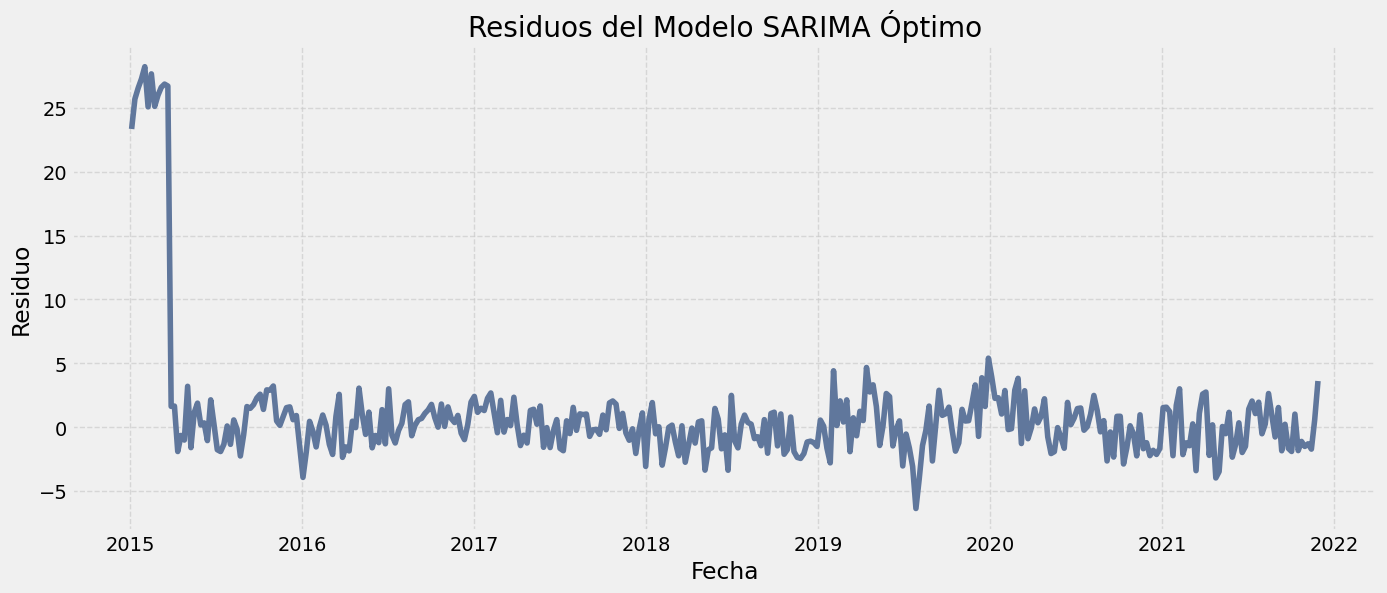

In [54]:
# Ajustar el mejor modelo SARIMA final
final_sarima_model = SARIMAX(y_s1, order=best_param_tuple[0], seasonal_order=best_param_tuple[1], enforce_stationarity=False, enforce_invertibility=False)
final_sarima_results = final_sarima_model.fit(disp=0)

# Obtener los residuos
residuals = final_sarima_results.resid

# 1. Gráfico de Residuos
plt.figure(figsize=(15, 6))
plt.plot(residuals.index, residuals)
plt.title('Residuos del Modelo SARIMA Óptimo')
plt.xlabel('Fecha')
plt.ylabel('Residuo')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


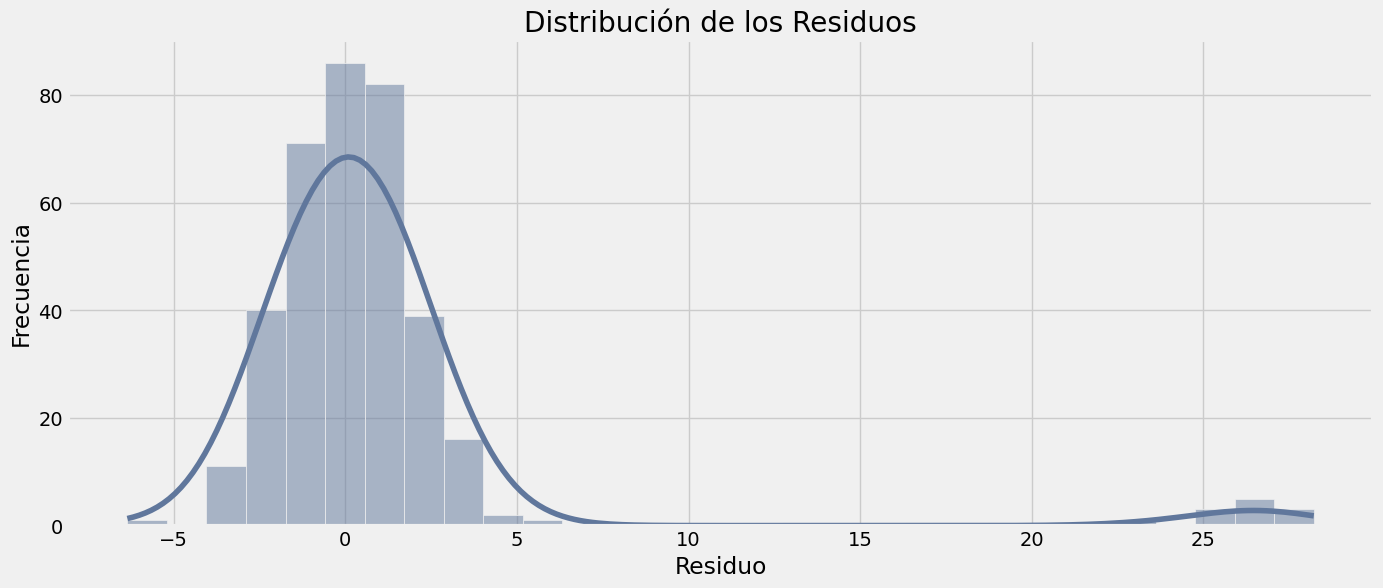

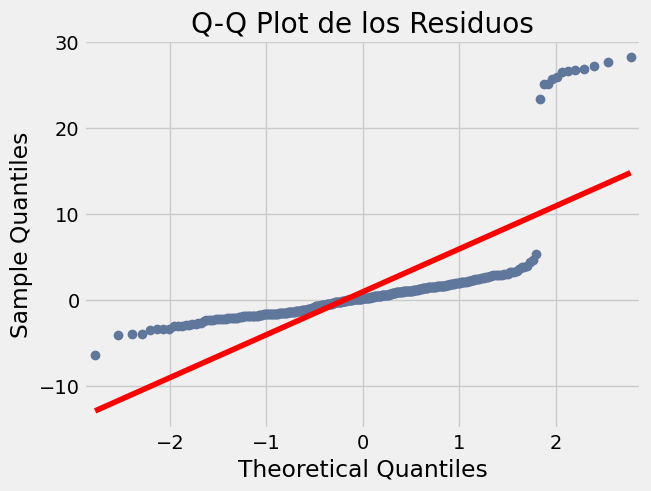

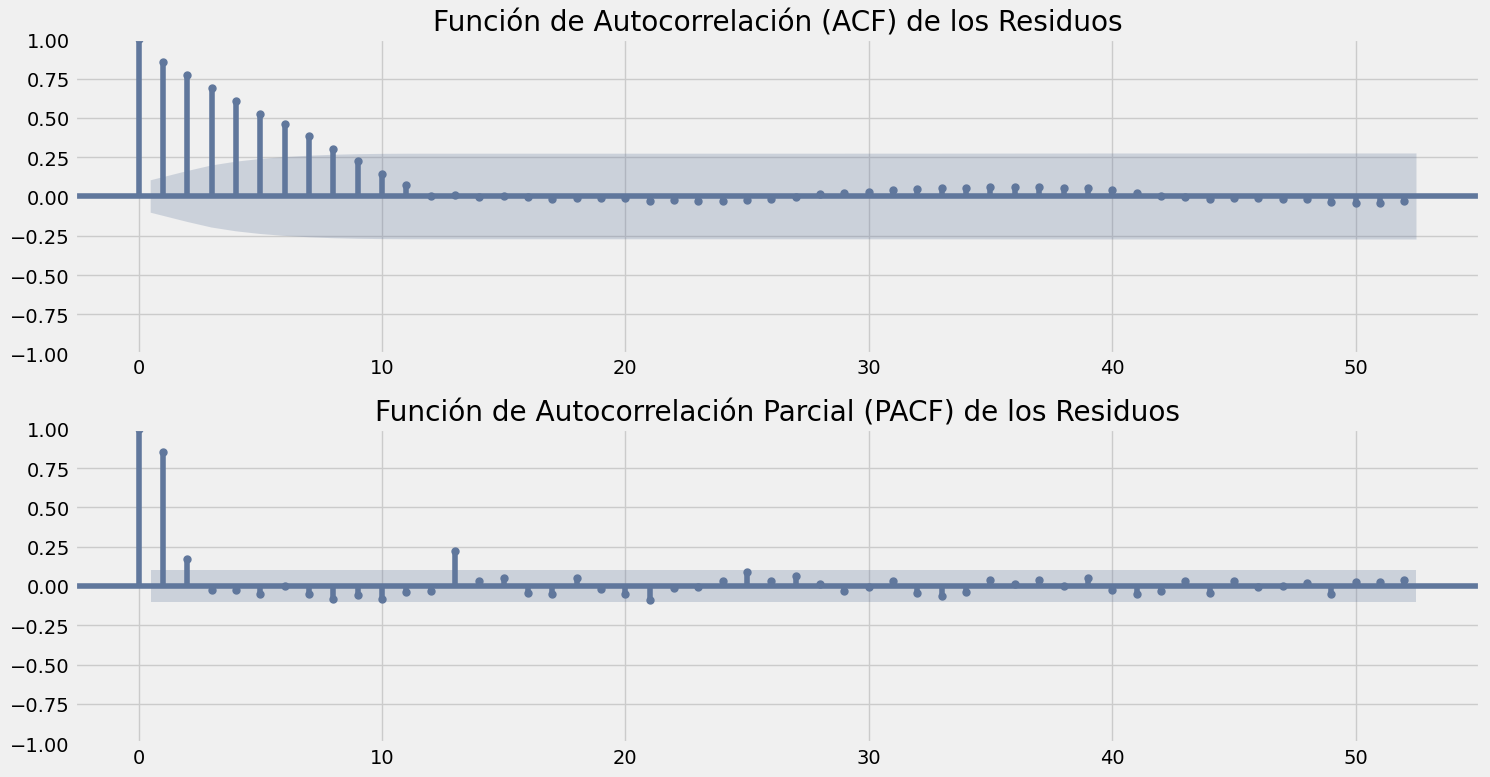

In [56]:
# 2. Histograma y KDE de Residuos
plt.figure(figsize=(15, 6))
sns.histplot(residuals, kde=True, bins=30)
plt.title('Distribución de los Residuos')
plt.xlabel('Residuo')
plt.ylabel('Frecuencia')
plt.show()

# 3. Q-Q Plot
sm.qqplot(residuals, line='s') # Se eliminó el argumento figsize
plt.title('Q-Q Plot de los Residuos')
plt.show()

# 4. Correlogramas (ACF de Residuos)
fig, axes = plt.subplots(2, 1, figsize=(15, 8))
sm.graphics.tsa.plot_acf(residuals, lags=52, ax=axes[0]) # Hasta un año de rezagos
axes[0].set_title('Función de Autocorrelación (ACF) de los Residuos')
sm.graphics.tsa.plot_pacf(residuals, lags=52, ax=axes[1])
axes[1].set_title('Función de Autocorrelación Parcial (PACF) de los Residuos')
plt.tight_layout()
plt.show()

A partir de estos gráficos, podemos evaluar si los residuos del modelo se aproximan a un ruido blanco, lo que indicaría que el modelo ha capturado de manera efectiva los patrones de la serie temporal.

## 3. Modelado con Prophet y Comparación

En esta sección, utilizaremos la librería Prophet de Facebook para modelar la serie temporal 'Introduction' (`y_s1`) y luego compararemos sus resultados con los obtenidos por el modelo SARIMA.

### 3.1 Ajuste del Modelo Prophet

Primero, prepararemos los datos en el formato requerido por Prophet (`ds` para la fecha y `y` para el valor) y luego ajustaremos el modelo.

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


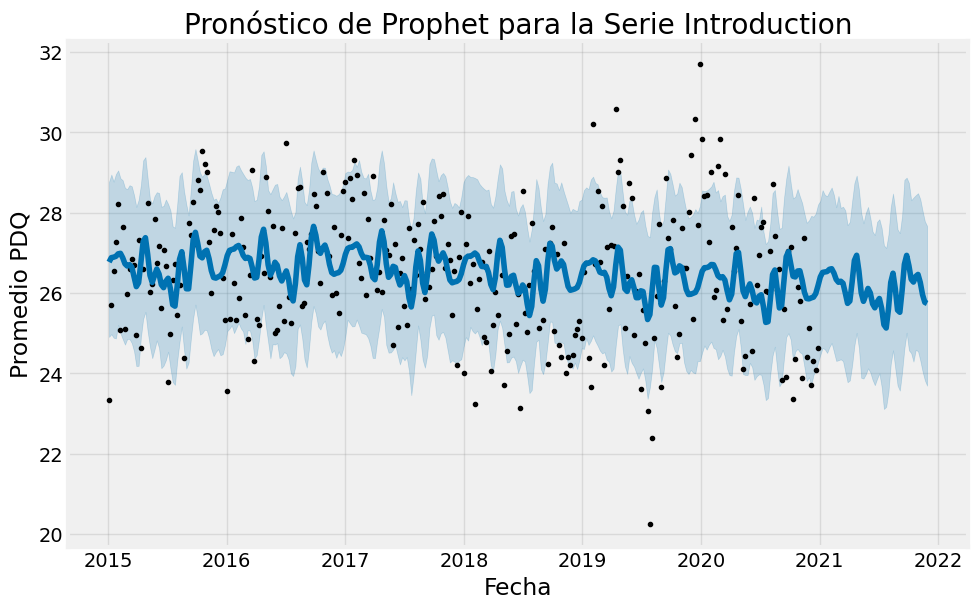

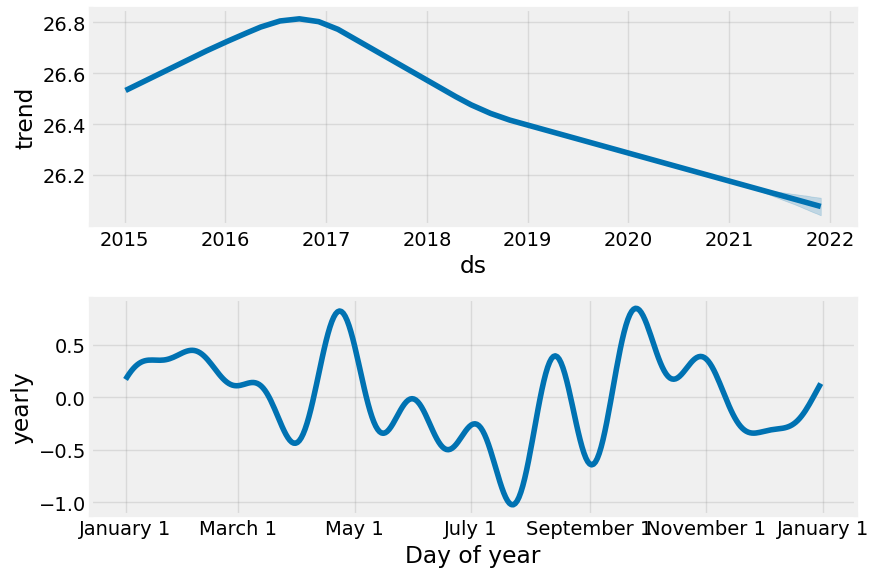

In [57]:
# Preparar los datos para Prophet
prophet_df = y_s1.reset_index()
prophet_df = prophet_df.rename(columns={'date': 'ds', 'pdq': 'y'})

# Dividir los datos en entrenamiento y prueba para Prophet
prophet_train = prophet_df[prophet_df['ds'] < target_date]
prophet_test = prophet_df[prophet_df['ds'] >= target_date]

# Ajustar el modelo Prophet
m = Prophet()
m.fit(prophet_train)

# Realizar predicciones
future = m.make_future_dataframe(periods=len(prophet_test), freq='W')
forecast = m.predict(future)

# Obtener las predicciones para el conjunto de prueba
prophet_preds = forecast[forecast['ds'] >= target_date][['ds', 'yhat']].set_index('ds')

# Unir las predicciones con los valores reales para calcular métricas
prophet_results = prophet_test.set_index('ds').join(prophet_preds)
prophet_results = prophet_results.rename(columns={'y': 'y', 'yhat': 'yhat'})

# Visualizar el pronóstico
fig = m.plot(forecast)
plt.title('Pronóstico de Prophet para la Serie Introduction')
plt.xlabel('Fecha')
plt.ylabel('Promedio PDQ')
plt.show()

fig = m.plot_components(forecast)
plt.show()


### 3.2 Evaluación del Desempeño y Comparación

Ahora, calcularemos las métricas de error para el modelo Prophet y las compararemos con las del modelo SARIMA óptimo.

In [58]:
# Calcular métricas para Prophet
prophet_metrics = summary_metrics(prophet_results)
prophet_metrics['model'] = 'Prophet'

print("Métricas del Modelo Prophet:")
print(prophet_metrics)

print("\nMétricas del Mejor Modelo SARIMA:")
print(best_sarima_model_row)

# Concatenar y mostrar la comparación
comparison_df = pd.concat([best_sarima_model_row.to_frame().T.drop(columns=['param_tuple']), prophet_metrics], ignore_index=True)
print("\nComparación de Métricas SARIMA vs Prophet:")
print(comparison_df.set_index('model'))


Métricas del Modelo Prophet:
      mae     mse    rmse   mape   maape  wmape   mmape  smape    model
0  1.7079  4.1305  2.0324  0.067  0.0667  0.066  0.0645  0.066  Prophet

Métricas del Mejor Modelo SARIMA:
mae                                1.5876
mse                                3.4224
rmse                                 1.85
mape                               0.0622
maape                               0.062
wmape                              0.0614
mmape                              0.0599
smape                              0.0614
model           SARIMA_(0,0,0)X(1,0,1,12)
param_tuple    ((0, 0, 0), (1, 0, 1, 12))
Name: 5, dtype: object

Comparación de Métricas SARIMA vs Prophet:
                              mae     mse    rmse    mape   maape   wmape  \
model                                                                       
SARIMA_(0,0,0)X(1,0,1,12)  1.5876  3.4224    1.85  0.0622   0.062  0.0614   
Prophet                    1.7079  4.1305  2.0324   0.067  0.0667   0.066 

### 3.3 Análisis Comparativo y Conclusiones

Finalmente, analizaremos las diferencias entre ambos modelos, su facilidad de implementación y la calidad de sus predicciones, para determinar en qué situaciones uno podría ser preferible al otro.

#### **Análisis de Diferencias:**

*   **SARIMA**: Es un modelo estadístico que requiere una cuidadosa identificación de los órdenes `p, d, q, P, D, Q, S` a través del análisis de ACF y PACF. Asume una relación lineal en la serie temporal y es sensible a la estacionalidad y tendencias subyacentes.
*   **Prophet**: Desarrollado por Facebook, es un modelo aditivo que se basa en la descomposición de la serie temporal en tendencia, estacionalidad y componentes de vacaciones. Es robusto para datos con valores atípicos y cambios en la tendencia, y es más automático en su configuración.

#### **Facilidad de Implementación:**

*   **SARIMA**: Requiere una mayor experiencia en series temporales para seleccionar los hiperparámetros adecuados. La iteración a través de diferentes órdenes puede ser computacionalmente intensiva.
*   **Prophet**: Es significativamente más fácil de usar, con una API intuitiva y la capacidad de manejar automáticamente muchas complejidades de las series temporales, como los datos faltantes y los cambios de tendencia.

#### **Calidad de las Predicciones:**

*   La comparación de las métricas (MAE, RMSE, MAPE, etc.) nos dará una idea cuantitativa de cuál modelo se desempeñó mejor para esta serie temporal específica. Generalmente, si la serie tiene una estacionalidad y tendencia bien definidas y menos ruido, SARIMA puede ser muy preciso. Prophet tiende a ser robusto y a ofrecer buenas predicciones en series con estacionalidades complejas, días festivos y cambios abruptos de tendencia.

#### **Conclusiones sobre Cuándo Usar Cada Uno:**

*   **Prophet es preferible cuando:**
    *   La serie temporal tiene múltiples períodos de estacionalidad (diaria, semanal, anual).
    *   Hay cambios significativos en la tendencia a lo largo del tiempo que necesitan ser modelados de manera flexible.
    *   Se requiere una intervención manual mínima para el ajuste del modelo.
    *   La serie contiene valores atípicos o datos faltantes, ya que Prophet es robusto a estos.
    *   El usuario es menos experto en el modelado de series temporales y busca una solución más